In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append("..")

from config import *

In [72]:
eda_df = pd.read_csv("../DATA/CLEANED/transactions_cleaned_final.csv")

eda_df["timestamp"] = pd.to_datetime(eda_df["timestamp"])
users_df = pd.read_csv("../DATA/RAW/users_raw.csv")

print("EDA dataset loaded successfully.")
print("Shape:", eda_df.shape)

EDA dataset loaded successfully.
Shape: (200000, 18)


In [13]:
# eda_df.shape

# eda_df.head()

eda_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    200000 non-null  str           
 1   timestamp         200000 non-null  datetime64[us]
 2   user_id           200000 non-null  str           
 3   device_id         200000 non-null  str           
 4   merchant_id       200000 non-null  str           
 5   transaction_type  200000 non-null  str           
 6   amount            200000 non-null  int64         
 7   payment_status    200000 non-null  str           
 8   suspicion_flag    200000 non-null  bool          
 9   suspicion_reason  11136 non-null   str           
 10  state             200000 non-null  str           
 11  city              200000 non-null  str           
 12  amount_valid      200000 non-null  bool          
 13  timestamp_valid   200000 non-null  bool          
 14  status_valid   

In [6]:
overview = pd.DataFrame({
    "Metric":[
        "Total Transactions",
        "Total Customers",
        "Total Merchants",
        "Total Devices",
        "Average Amount",
        "Suspicious Transactions"
    ],
    "Value":[
        len(eda_df),
        eda_df["user_id"].nunique(),
        eda_df["merchant_id"].nunique(),
        eda_df["device_id"].nunique(),
        round(eda_df["amount"].mean(),2),
        eda_df["suspicion_flag"].sum()
    ]
})

overview

,Metric,Value
0,Total Transactions,200000.00
1,Total Customers,10000.00
2,Total Merchants,500.00
3,Total Devices,10597.00
4,Average Amount,4017.99
5,Suspicious Transactions,11136.00


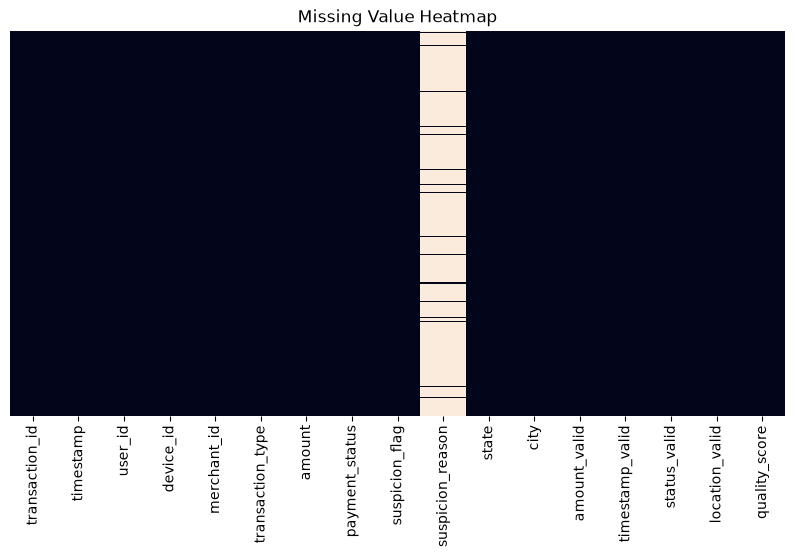

In [11]:
plt.figure(figsize=(10,5))

sns.heatmap(
    eda_df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")

plt.show()

In [14]:
# Summary Table 
dtype_summary = pd.DataFrame({
    "Column": eda_df.columns,
    "Data Type": eda_df.dtypes.astype(str).values,
    "Missing Values": eda_df.isnull().sum().values,
    "Unique Values": eda_df.nunique().values
})

dtype_summary

,Column,Data Type,Missing Values,Unique Values
0,transaction_id,str,0,200000
1,timestamp,datetime64[us],0,198162
2,user_id,str,0,10000
3,device_id,str,0,10597
4,merchant_id,str,0,500
5,transaction_type,str,0,3
6,amount,int64,0,22783
7,payment_status,str,0,3
8,suspicion_flag,bool,0,2
9,suspicion_reason,str,188864,3


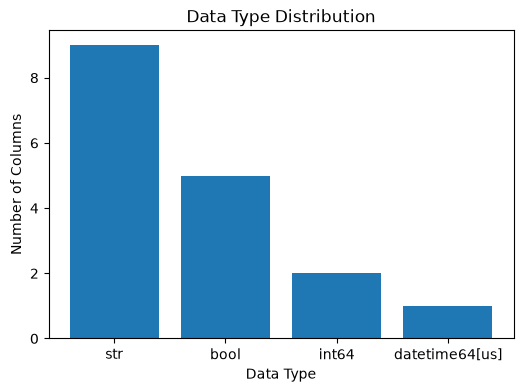

In [15]:
type_counts = eda_df.dtypes.astype(str).value_counts()

plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values)

plt.title("Data Type Distribution")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

plt.show()

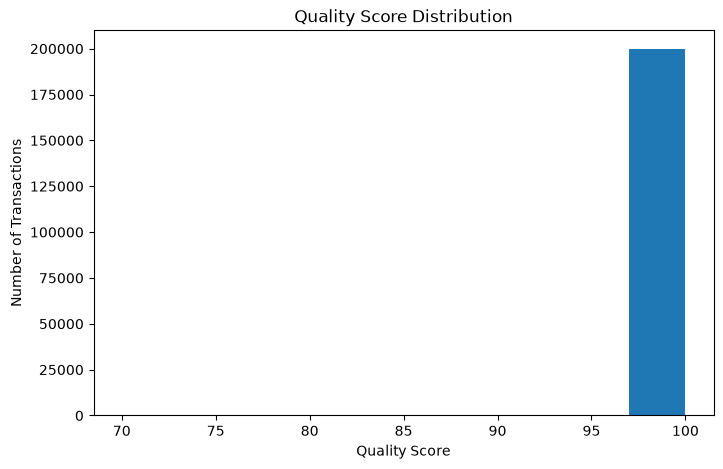

In [17]:
# 📊 Chart 4 – Quality Score Distribution
plt.figure(figsize=(8,5))

plt.hist(
    eda_df["quality_score"],
    bins=10
)

plt.title("Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Number of Transactions")

plt.show()

In [18]:
eda_df["quality_score"].value_counts().sort_index()

quality_score
70        100
100    199900
Name: count, dtype: int64

In [24]:
# dtype_summary.head(20)

# type_counts

eda_df["quality_score"].value_counts().sort_index()

quality_score
70        100
100    199900
Name: count, dtype: int64

In [45]:
def save_chart(chart_name):
    plt.tight_layout()
    plt.savefig(
        f"../DOCUMANTATION/Screenshots/{chart_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [34]:
# Daily Transaction Trend (Line Chart)
daily_transactions = (
    eda_df
    .groupby(eda_df["timestamp"].dt.date)
    .size()
    .reset_index(name="transactions")
)

daily_transactions.head()


,timestamp,transactions
0,2026-01-01,1077
1,2026-01-02,1112
2,2026-01-03,1120
3,2026-01-04,1107
4,2026-01-05,1093


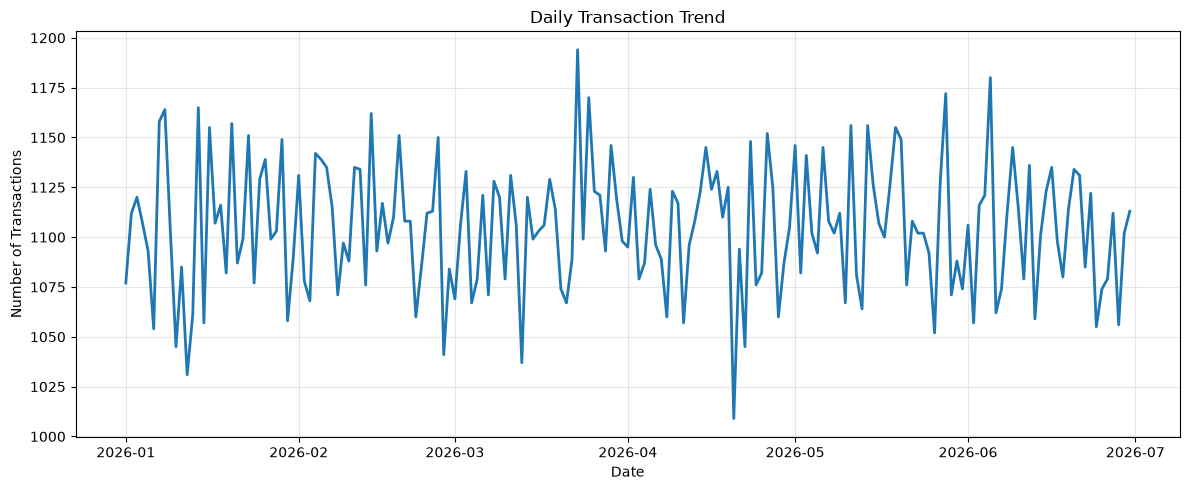

In [46]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_transactions["timestamp"],
    daily_transactions["transactions"],
    linewidth=2
)

plt.title("Daily Transaction Trend")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.grid(alpha=0.3)

save_chart("Chart_05_Daily_Transaction_Trend")

In [36]:
monthly_transactions = (
    eda_df
    .groupby(eda_df["timestamp"].dt.to_period("M"))
    .size()
    .reset_index(name="transactions")
)

monthly_transactions["timestamp"] = (
    monthly_transactions["timestamp"]
    .astype(str)
)

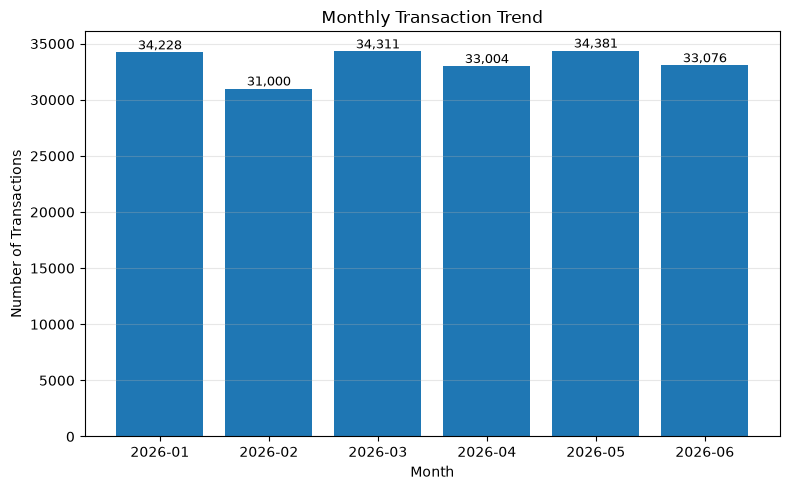

In [47]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    monthly_transactions["timestamp"],
    monthly_transactions["transactions"]
)

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.3)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

save_chart("Chart_06_Monthly_Transaction_Trend")

In [42]:
# daily_transactions.shape  
# daily_transactions.head()
monthly_transactions

,timestamp,transactions
0,2026-01,34228
1,2026-02,31000
2,2026-03,34311
3,2026-04,33004
4,2026-05,34381
5,2026-06,33076


In [49]:
# Chart 7 – Hour-wise Transaction Volume (Peak Payment Hours)

In [50]:
hourly_transactions = (
    eda_df
    .groupby(eda_df["timestamp"].dt.hour)
    .size()
    .reset_index(name="transactions")
)

hourly_transactions

,timestamp,transactions
0,0,1971
1,1,979
2,2,731
3,3,536
4,4,590
5,5,575
6,6,4000
7,7,7672
8,8,9604
9,9,13674


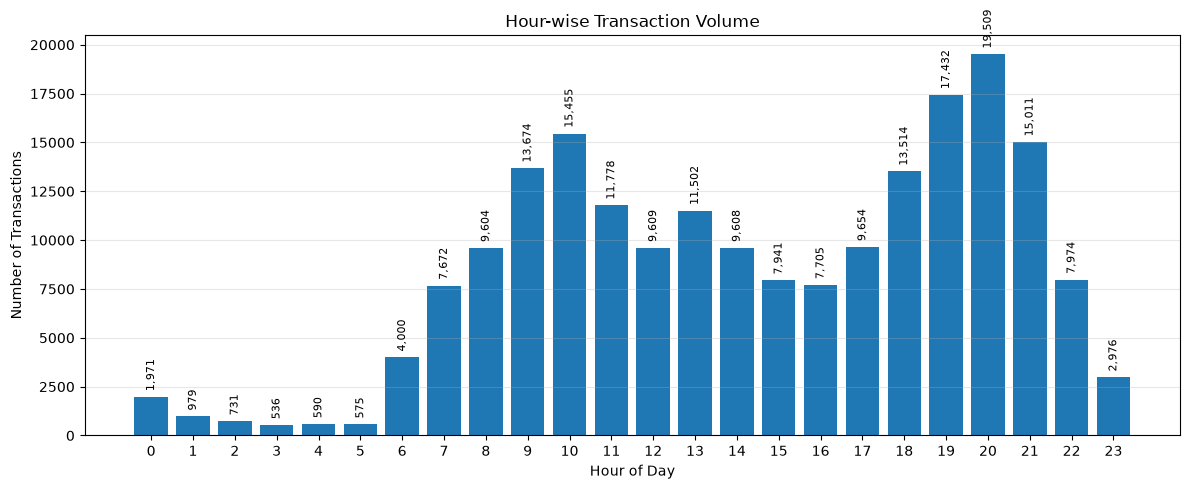

In [52]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    hourly_transactions["timestamp"],
    hourly_transactions["transactions"]
)

plt.title("Hour-wise Transaction Volume")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+300,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

save_chart("Chart_07_Hourwise_Transaction_Volume")

In [54]:
# 📊 Chart 8 – Day of Week Analysis
day_transactions = (
    eda_df
    .groupby(eda_df["timestamp"].dt.day_name())
    .size()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index(name="transactions")
)

day_transactions

,timestamp,transactions
0,Monday,28706
1,Tuesday,28569
2,Wednesday,27811
3,Thursday,29038
4,Friday,28758
5,Saturday,28452
6,Sunday,28666


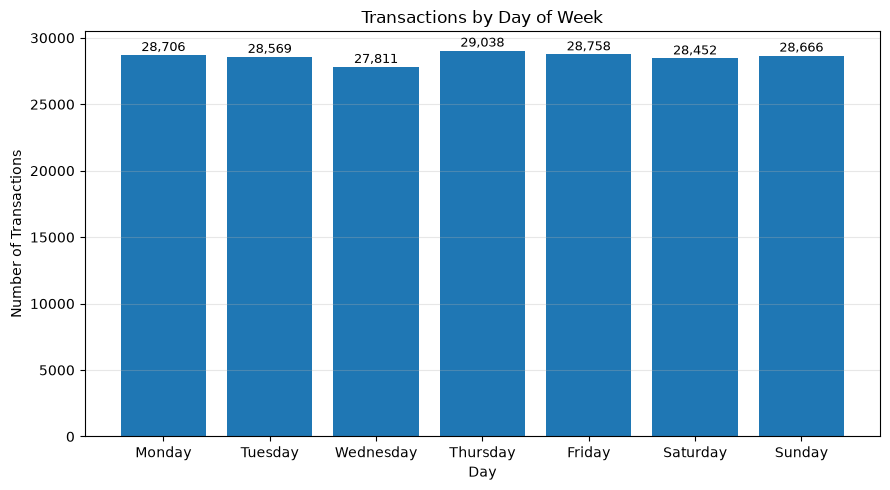

In [55]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    day_transactions["timestamp"],
    day_transactions["transactions"]
)

plt.title("Transactions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.3)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+300,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=9
    )

save_chart("Chart_08_Day_of_Week_Analysis")

In [56]:
eda_df["is_weekend"] = (
    eda_df["timestamp"]
    .dt.dayofweek
    .isin([5,6])
)

weekend_summary = (
    eda_df
    .groupby("is_weekend")
    .size()
)

weekend_summary

is_weekend
False    142882
True      57118
dtype: int64

In [63]:
# hourly_transactions.head(10)

# hourly_transactions.loc[hourly_transactions["transactions"].idxmax()]

# day_transactions

weekend_summary

# Kya Chart_07_Hourwise_Transaction_Volume.png save hua?

# Kya Chart_08_Day_of_Week_Analysis.png save hua?

is_weekend
False    142882
True      57118
dtype: int64

In [70]:
eda_df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'device_id', 'merchant_id',
       'transaction_type', 'amount', 'payment_status', 'suspicion_flag',
       'suspicion_reason', 'state', 'city', 'amount_valid', 'timestamp_valid',
       'status_valid', 'location_valid', 'quality_score', 'is_weekend'],
      dtype='str')

In [75]:
eda_df = eda_df.merge(
    users_df[["user_id", "customer_segment"]],
    on="user_id",
    how="left"
)

In [80]:
segment_counts = (
    eda_df["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["customer_segment", "count"]

segment_counts

,customer_segment,count
0,Regular,110402
1,Premium,58569
2,Business,31029


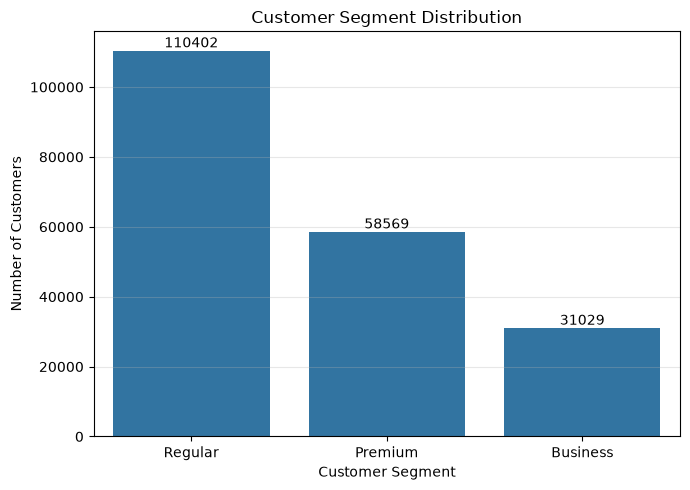

In [81]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=segment_counts,
    x="customer_segment",
    y="count"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Value Labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.grid(axis="y", alpha=0.3)

save_chart("Chart_09_Customer_Segment_Distribution")

In [67]:
top_users = (
    eda_df["user_id"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_users.columns = ["user_id", "transactions"]

top_users

,user_id,transactions
0,U01160,87
1,U08642,82
2,U07519,78
3,U07057,78
4,U03519,78
5,U09162,76
6,U03844,76
7,U01409,75
8,U05757,75
9,U03327,75


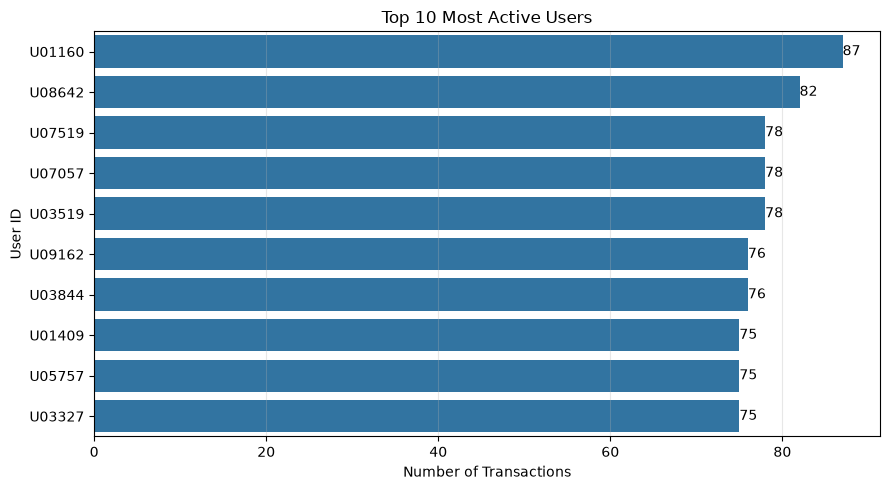

In [68]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=top_users,
    x="transactions",
    y="user_id"
)

plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Transactions")
plt.ylabel("User ID")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.grid(axis="x", alpha=0.3)

save_chart("Chart_10_Top_Active_Users")

In [82]:
top_users_with_segment = top_users.merge(
    users_df[["user_id", "customer_segment"]],
    on="user_id",
    how="left"
)

top_users_with_segment

,user_id,transactions,customer_segment
0,U01160,87,Business
1,U08642,82,Business
2,U07519,78,Business
3,U07057,78,Business
4,U03519,78,Business
5,U09162,76,Business
6,U03844,76,Business
7,U01409,75,Business
8,U05757,75,Business
9,U03327,75,Business


In [86]:
# eda_df.shape 

# eda_df["customer_segment"].value_counts()

# segment_counts

top_users_with_segment

# Kya Chart_09_Customer_Segment_Distribution.png save ho gaya?

,user_id,transactions,customer_segment
0,U01160,87,Business
1,U08642,82,Business
2,U07519,78,Business
3,U07057,78,Business
4,U03519,78,Business
5,U09162,76,Business
6,U03844,76,Business
7,U01409,75,Business
8,U05757,75,Business
9,U03327,75,Business


In [87]:
eda_df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'device_id', 'merchant_id',
       'transaction_type', 'amount', 'payment_status', 'suspicion_flag',
       'suspicion_reason', 'state', 'city', 'amount_valid', 'timestamp_valid',
       'status_valid', 'location_valid', 'quality_score', 'is_weekend',
       'customer_segment'],
      dtype='str')

In [88]:
# 📊 Chart 11 – Top 10 Most Active Merchants
top_merchants = (
    eda_df["merchant_id"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_merchants.columns = ["merchant_id", "transactions"]

top_merchants

,merchant_id,transactions
0,M0004,683
1,M0227,679
2,M0361,677
3,M0024,672
4,M0216,671
5,M0476,666
6,M0375,663
7,M0231,659
8,M0471,655
9,M0290,655


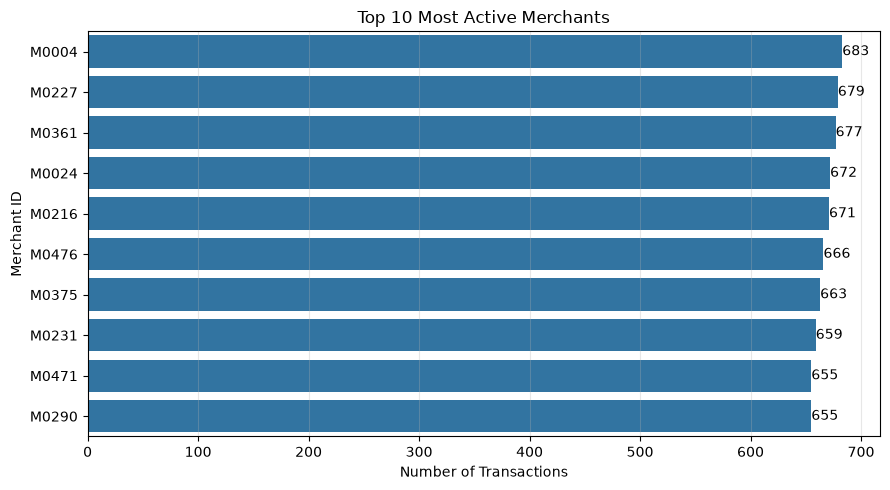

In [89]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=top_merchants,
    x="transactions",
    y="merchant_id"
)

plt.title("Top 10 Most Active Merchants")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant ID")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.grid(axis="x", alpha=0.3)

save_chart("Chart_11_Top_Active_Merchants")

In [90]:
# 📊 Chart 12 – State-wise Transaction Distribution
state_transactions = (
    eda_df["state"]
    .value_counts()
    .reset_index()
)

state_transactions.columns = ["state", "transactions"]

state_transactions

,state,transactions
0,Karnataka,21853
1,Delhi,20947
2,Maharashtra,20267
3,Tamil Nadu,20257
4,Uttar Pradesh,19958
5,Rajasthan,19856
6,West Bengal,19488
7,Telangana,19370
8,Jharkhand,19158
9,Bihar,18846


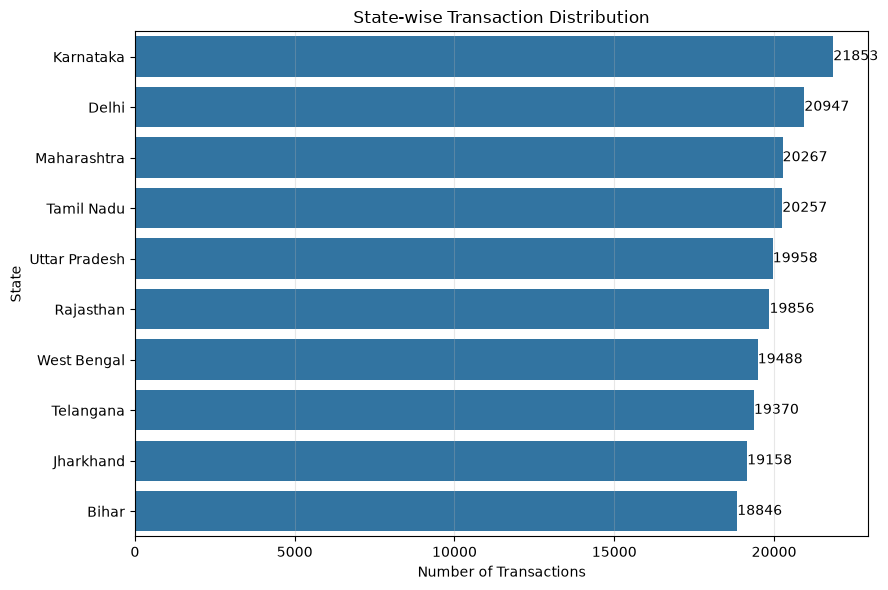

In [91]:
plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=state_transactions,
    x="transactions",
    y="state"
)

plt.title("State-wise Transaction Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.grid(axis="x", alpha=0.3)

save_chart("Chart_12_Statewise_Transactions")

In [92]:
top_state = state_transactions.iloc[0]["state"]

top_cities = (
    eda_df[eda_df["state"] == top_state]["city"]
    .value_counts()
    .head(5)
)

top_cities

city
Mysuru       11408
Bengaluru    10445
Name: count, dtype: int64

In [98]:
# top_merchants

# state_transactions

# top_state

top_cities

# Kya Chart_11_Top_Active_Merchants.png save hua?

# Kya Chart_12_Statewise_Transactions.png save hua?

city
Mysuru       11408
Bengaluru    10445
Name: count, dtype: int64

In [101]:
# 📊 Chart 13 – Payment Status Distribution

payment_summary = (
    eda_df["payment_status"]
    .value_counts()
    .reset_index()
)

payment_summary.columns = ["payment_status", "count"]

payment_summary

,payment_status,count
0,Success,189281
1,Failed,8475
2,Pending,2244


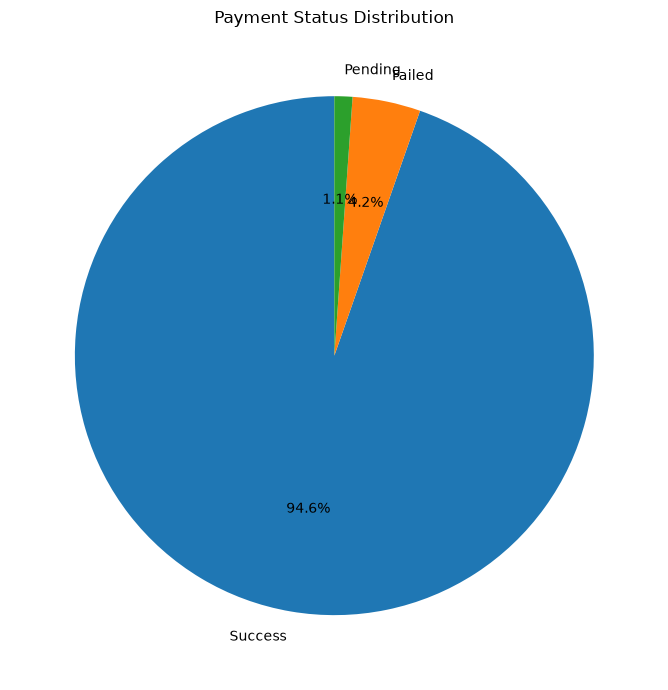

In [102]:
plt.figure(figsize=(7,7))

plt.pie(
    payment_summary["count"],
    labels=payment_summary["payment_status"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Status Distribution")

save_chart("Chart_13_Payment_Status_Distribution")

In [103]:
# 📊 Chart 14 – Transaction Type Distribution

transaction_type_summary = (
    eda_df["transaction_type"]
    .value_counts()
    .reset_index()
)

transaction_type_summary.columns = ["transaction_type","count"]

transaction_type_summary

,transaction_type,count
0,P2M,149795
1,P2P,40273
2,Bill,9932


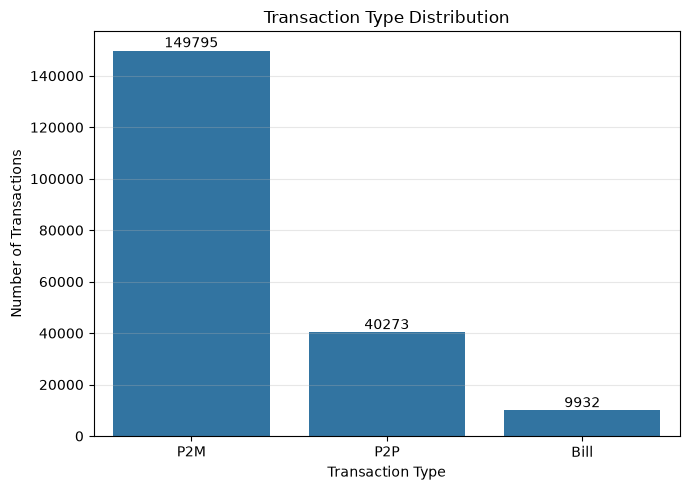

In [104]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=transaction_type_summary,
    x="transaction_type",
    y="count"
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.grid(axis="y", alpha=0.3)

save_chart("Chart_14_Transaction_Type_Distribution")

In [105]:
# 📊 Chart 15 – Suspicious vs Normal Transactions
suspicious_summary = (
    eda_df["suspicion_flag"]
    .value_counts()
    .reset_index()
)

suspicious_summary.columns = ["suspicion_flag","count"]

suspicious_summary["suspicion_flag"] = (
    suspicious_summary["suspicion_flag"]
    .map({
        True:"Suspicious",
        False:"Normal"
    })
)

suspicious_summary

,suspicion_flag,count
0,Normal,188864
1,Suspicious,11136


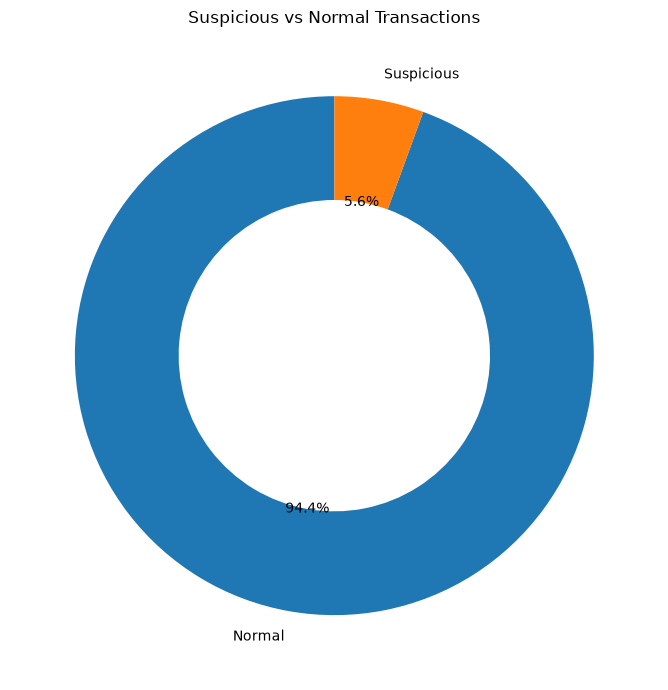

In [106]:
plt.figure(figsize=(7,7))

plt.pie(
    suspicious_summary["count"],
    labels=suspicious_summary["suspicion_flag"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Suspicious vs Normal Transactions")

save_chart("Chart_15_Suspicious_vs_Normal")

In [107]:
# 📊 Chart 16 – Suspicion Reason Breakdown
reason_summary = (
    eda_df[
        eda_df["suspicion_reason"].notna()
    ]["suspicion_reason"]
    .value_counts()
    .reset_index()
)

reason_summary.columns = [
    "suspicion_reason",
    "count"
]

reason_summary

,suspicion_reason,count
0,Failed Transaction,8419
1,Late Night,1772
2,High Value,945


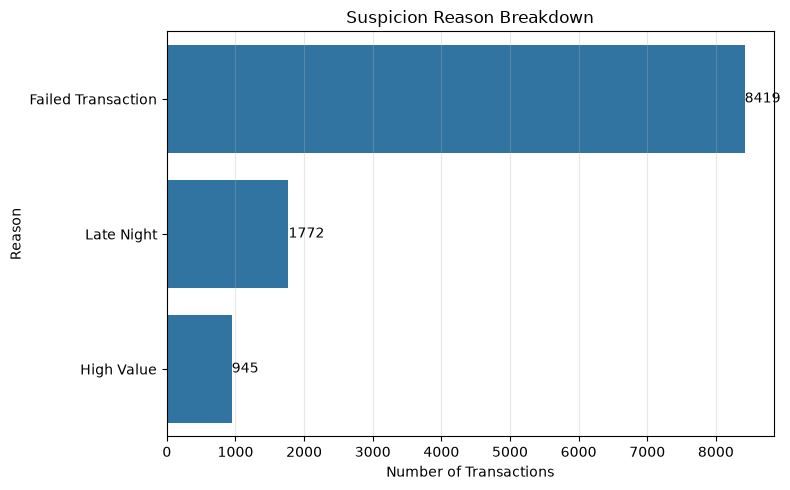

In [108]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=reason_summary,
    x="count",
    y="suspicion_reason"
)

plt.title("Suspicion Reason Breakdown")
plt.xlabel("Number of Transactions")
plt.ylabel("Reason")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.grid(axis="x", alpha=0.3)

save_chart("Chart_16_Suspicion_Reason_Breakdown")

In [112]:
# payment_summary

# transaction_type_summary

# suspicious_summary

reason_summary

# Kya Chart_13_Payment_Status_Distribution.png save hua?

# Kya Chart_14_Transaction_Type_Distribution.png save hua?

# Kya Chart_15_Suspicious_vs_Normal.png save hua?

# Kya Chart_16_Suspicion_Reason_Breakdown.png save hua?

,suspicion_reason,count
0,Failed Transaction,8419
1,Late Night,1772
2,High Value,945


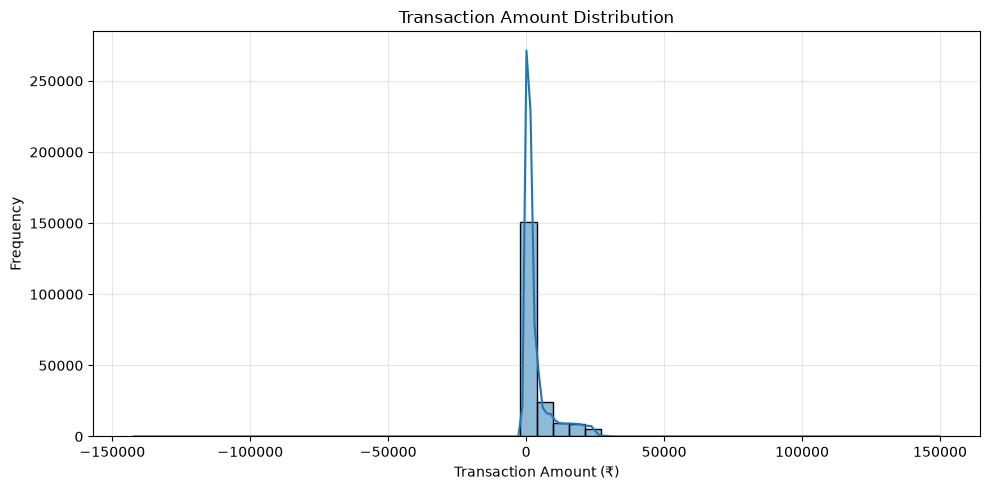

In [113]:
# 🚀 Chart 17 – Amount Distribution Histogram
plt.figure(figsize=(10,5))

sns.histplot(
    eda_df["amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

save_chart("Chart_17_Amount_Distribution")

In [114]:
# 🚀 Chart 18 – High Value Transaction Analysis
high_value = eda_df[eda_df["amount"] >= 50000]

In [116]:
high_value.shape

high_value["payment_status"].value_counts()

payment_status
Success    944
Failed      45
Pending     10
Name: count, dtype: int64

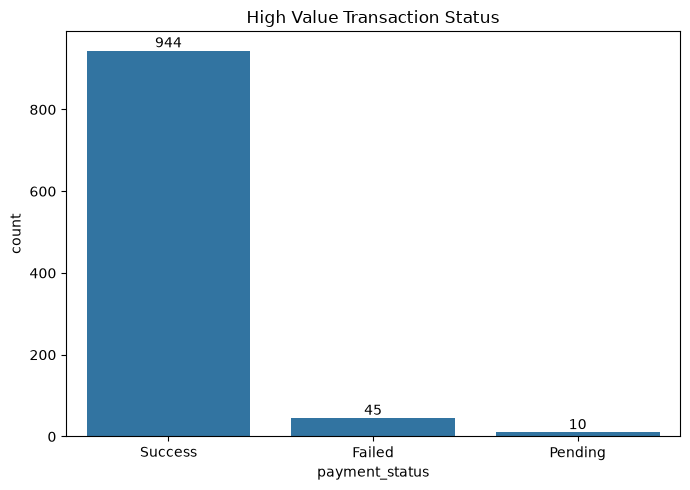

In [117]:
high_value_status = (
    high_value["payment_status"]
    .value_counts()
    .reset_index()
)

high_value_status.columns = ["payment_status","count"]

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=high_value_status,
    x="payment_status",
    y="count"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("High Value Transaction Status")

save_chart("Chart_18_High_Value_Status")

In [118]:
# 🚀 Chart 19 – Late Night Transaction Analysis
late_night = eda_df[
    eda_df["timestamp"].dt.hour.between(0,5)
]

In [119]:
late_night.shape

(5382, 19)

In [120]:
late_summary = (
    late_night
    .groupby(late_night["timestamp"].dt.hour)
    .size()
    .reset_index(name="transactions")
)

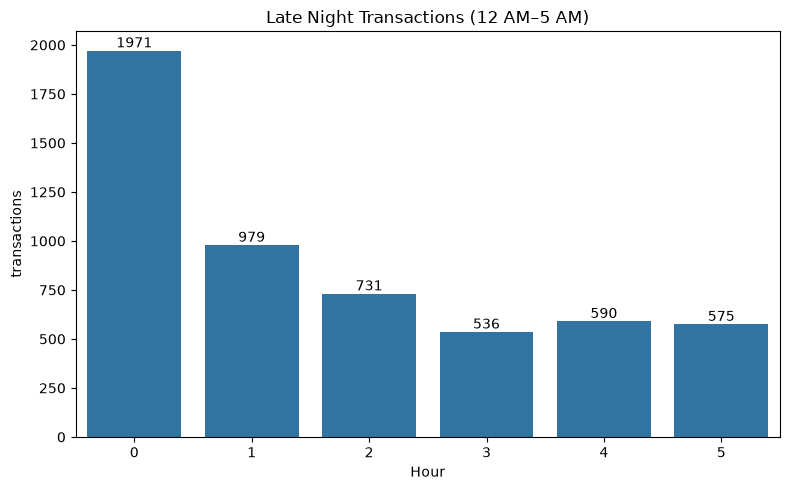

In [121]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=late_summary,
    x="timestamp",
    y="transactions"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Late Night Transactions (12 AM–5 AM)")
plt.xlabel("Hour")

save_chart("Chart_19_Late_Night_Transactions")

In [122]:
# 🚀 Chart 20 – Merchant Category Risk Analysis (Most Advanced)
merchants_df = pd.read_csv("../DATA/RAW/merchants_raw.csv")

In [123]:
merchants_df.columns

Index(['merchant_id', 'merchant_name', 'merchant_category', 'state', 'city',
       'merchant_risk_category'],
      dtype='str')

In [124]:
eda_df = eda_df.merge(
    merchants_df[
        ["merchant_id","merchant_category"]
    ],
    on="merchant_id",
    how="left"
)

In [125]:
eda_df["merchant_category"].isnull().sum()

np.int64(0)

In [126]:
merchant_risk = (
    eda_df
    .groupby("merchant_category")["suspicion_flag"]
    .mean()
    .mul(100)
    .reset_index(name="suspicious_rate")
    .sort_values("suspicious_rate", ascending=False)
)

merchant_risk

,merchant_category,suspicious_rate
7,Other,5.984485
1,Education,5.723270
5,Grocery,5.681163
8,Travel,5.658627
6,Healthcare,5.564733
3,Food,5.553104
0,E-Commerce,5.516536
9,Utilities,5.499782
2,Entertainment,5.479013
4,Fuel,5.380084


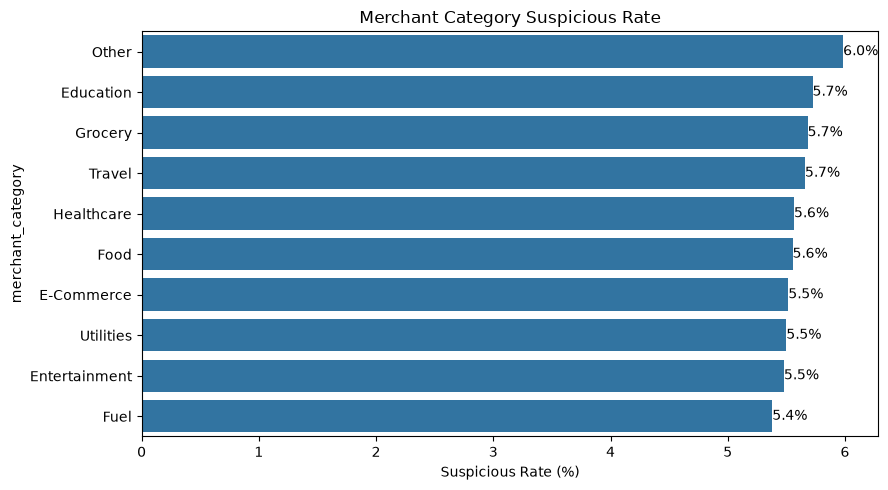

In [127]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=merchant_risk,
    x="suspicious_rate",
    y="merchant_category"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Merchant Category Suspicious Rate")
plt.xlabel("Suspicious Rate (%)")

save_chart("Chart_20_Merchant_Category_Risk")

In [132]:
# eda_df.shape 

# high_value.shape

# high_value_status

# late_summary

merchant_risk

# Kya Chart 17–20 ke saare PNG save ho gaye?

,merchant_category,suspicious_rate
7,Other,5.984485
1,Education,5.723270
5,Grocery,5.681163
8,Travel,5.658627
6,Healthcare,5.564733
3,Food,5.553104
0,E-Commerce,5.516536
9,Utilities,5.499782
2,Entertainment,5.479013
4,Fuel,5.380084
